## Image Based Car Damage Detection
------------------------

### Buisness Case:
- Based on the provided image data, our objective is to develop a classification system that categorizes images into two distinct classes Damage and Not Damage.

### Import Required Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imghdr
import cv2
import random

import tensorflow
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, Dense, MaxPooling2D, BatchNormalization, Dropout, Flatten
from keras.optimizers import Adam, Adamax
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from sklearn.metrics import confusion_matrix, classification_report, auc, roc_curve, f1_score

In [3]:
def img_count_subdirs(dir_name, set_name):
    count = {}

    for sub_dir_name in os.listdir(dir_name):
        sub_dir_path = os.path.join(dir_name, sub_dir_name)

        if os.path.isdir(sub_dir_path):
            count[sub_dir_name] = len(os.listdir(sub_dir_path))

    df = pd.DataFrame(count, index=[set_name])
    return df

In [4]:
train_dir = "./dataset/training"

train_count = img_count_subdirs(train_dir, "train")
train_count

,damage,whole
train,920,920


<Axes: >

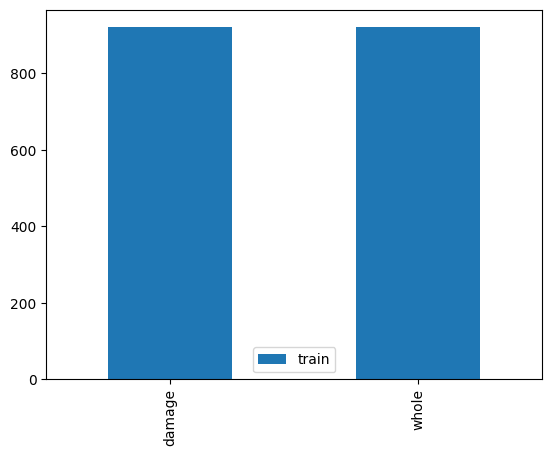

In [5]:
train_count.T.plot(kind="bar")

In [34]:
test_dir = "./dataset/testing"

test_count = img_count_subdirs(test_dir, "testing")
test_count

,damage,whole
testing,230,230


<Axes: >

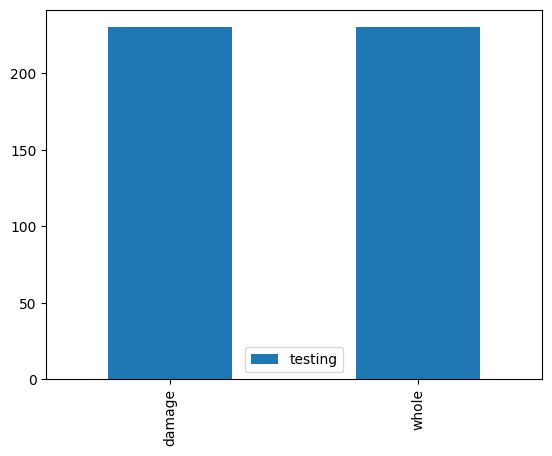

In [35]:
test_count.T.plot(kind="bar")

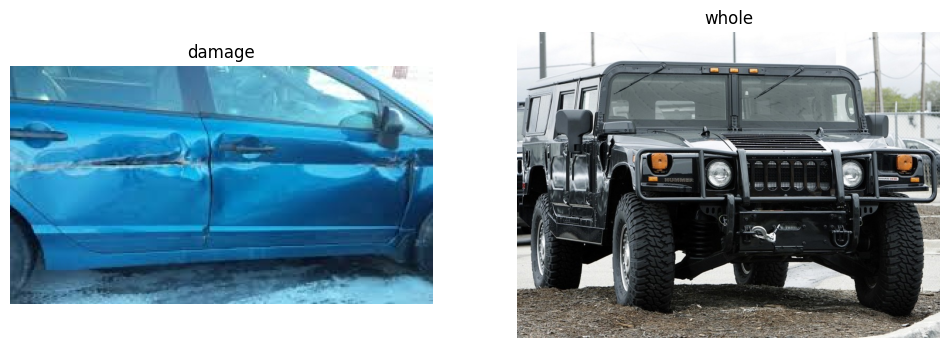

In [8]:
train_dir = "./dataset/training"

classes = os.listdir(train_dir)

plt.figure(figsize=(12, 8))

for i, class_ in enumerate(classes, 1):
    folder = os.path.join(train_dir, class_)
    img_path = os.path.join(folder, os.listdir(folder)[3])
    img = plt.imread(img_path)

    plt.subplot(1, 2, i)
    plt.imshow(img)

    plt.title(class_)
    plt.axis("off")

In [9]:
def plot_img(dir_path, class_name, num_img=9):
    img_path = os.listdir(dir_path)

    if len(img_path) < num_img:
        num_img = len(img_path)

    random_imgs = random.sample(img_path, num_img)

    fig, ax = plt.subplots(3,3, figsize=(8,8))
    ax = ax.ravel()

    for i, img in enumerate(random_imgs):
        img_path = os.path.join(dir_path, img)

        image = load_img(img_path)
        ax[i].imshow(image)
        ax[i].axis("off")
        
    plt.tight_layout()
    plt.show()

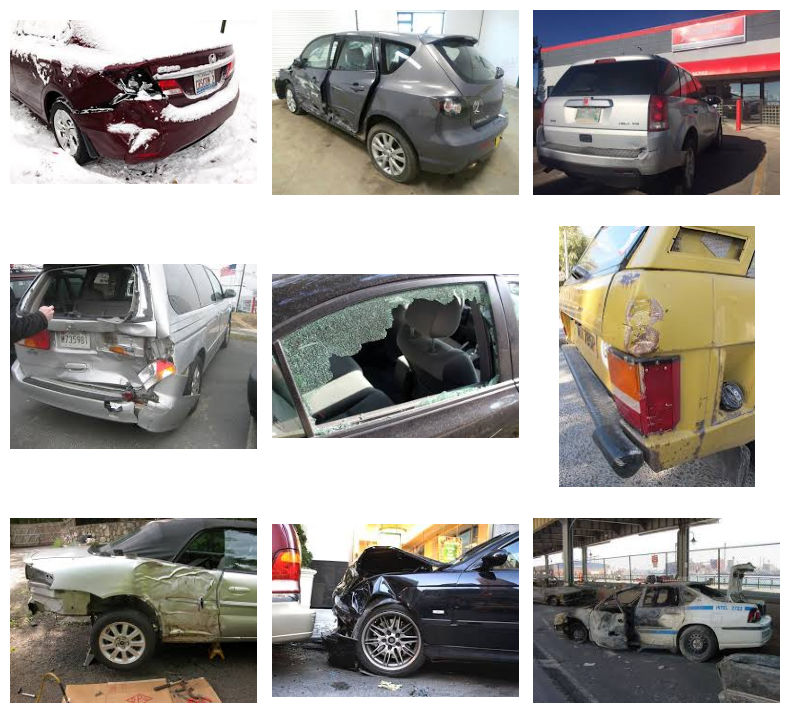

In [10]:
plot_img("./dataset/training/damage", class_name="damage")

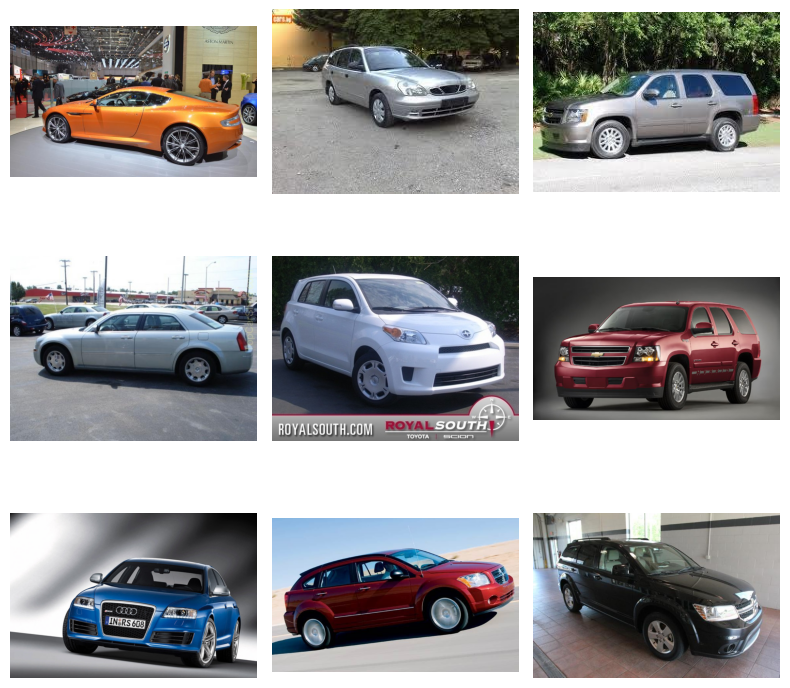

In [11]:
plot_img("./dataset/training/whole", class_name="whole")

### Model 1 : Custom CNN 

In [12]:
train_dir = "./dataset/training"
test_dir = "./dataset/testing"

In [ ]:
# img_width, img_height = 48, 48
# img_width, img_height = 128, 128
img_width, img_height = 64, 64
batch_size = 32
epochs = 10
num_class = 2

In [14]:
data_gen = ImageDataGenerator(
    rescale = 1/255,
    validation_split = 0.2
)

In [15]:
train_generator = data_gen.flow_from_directory(
    train_dir,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = "categorical",
    color_mode = "grayscale",
    subset = "training"
)

val_generator = data_gen.flow_from_directory(
    train_dir,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = "categorical",
    color_mode = "grayscale",
    subset = "validation"
)

test_generator = data_gen.flow_from_directory(
    test_dir,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = "categorical",
    color_mode = "grayscale"
)

Found 1472 images belonging to 2 classes.
Found 368 images belonging to 2 classes.
Found 460 images belonging to 2 classes.


In [16]:
train_class_labels = train_generator.class_indices
print("Training class labels:", train_class_labels)

validation_class_labels = val_generator.class_indices
print("Validation class labels:", validation_class_labels)

test_class_labels = test_generator.class_indices
print("Testing class labels:", test_class_labels)

Training class labels: {'damage': 0, 'whole': 1}
Validation class labels: {'damage': 0, 'whole': 1}
Testing class labels: {'damage': 0, 'whole': 1}


In [17]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation="relu", padding="same", input_shape=(img_width, img_height, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(128, kernel_size=(3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(2, activation="softmax"))

model.summary()

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 626,498 (2.39 MB)

 Trainable params: 626,050 (2.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=5,
    verbose=1,
    restore_best_weights=True
    )

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[earlystop]
)

Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.5469 - loss: 0.8456 - val_accuracy: 0.5000 - val_loss: 1.1027
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.6141 - loss: 0.6389 - val_accuracy: 0.5000 - val_loss: 1.0014
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.6216 - loss: 0.6418 - val_accuracy: 0.5000 - val_loss: 1.1030
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.6202 - loss: 0.6441 - val_accuracy: 0.5000 - val_loss: 1.5637
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.6698 - loss: 0.5890 - val_accuracy: 0.5000 - val_loss: 1.4861
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.6773 - loss: 0.5793 - val_accuracy: 0.5245 - val_loss: 0.8756
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.6929 - loss: 0.5627 - val_accuracy: 0.5598 - val_loss: 1.4451
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.7126 - loss: 0.5339 - val_accuracy: 0.

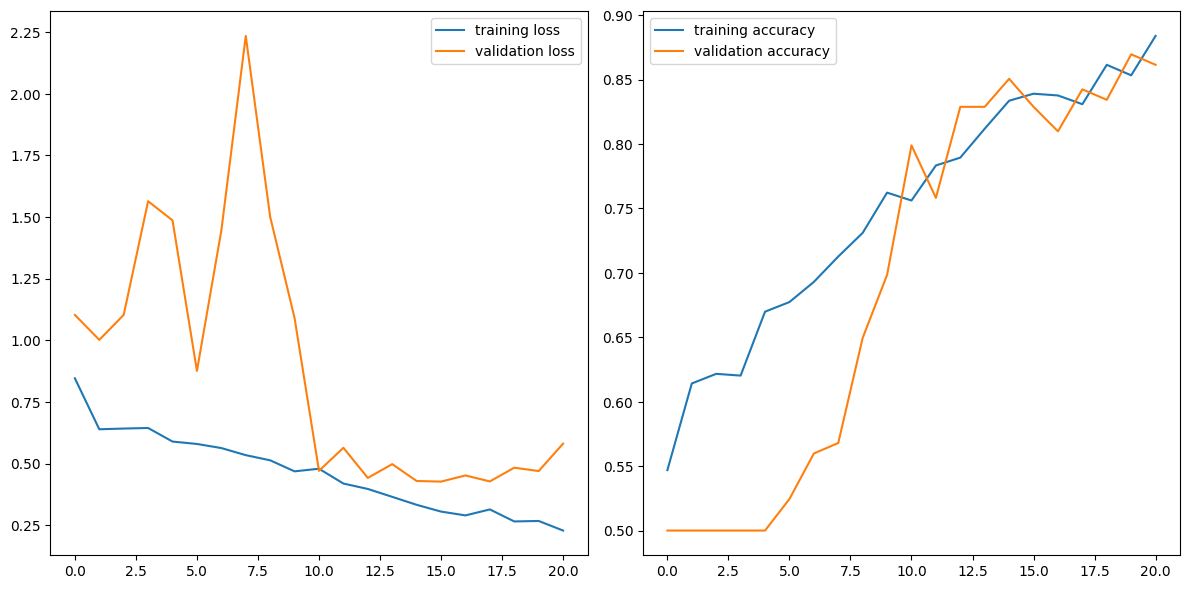

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.lineplot(history.history["loss"], ax=ax[0], label="training loss")
sns.lineplot(history.history["val_loss"], ax=ax[0], label="validation loss")

sns.lineplot(history.history["accuracy"], ax=ax[1], label="training accuracy")
sns.lineplot(history.history["val_accuracy"], ax=ax[1], label="validation accuracy")

plt.tight_layout()
plt.show()

In [22]:
train_loss, train_accuracy = model.evaluate(train_generator)
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Accuracy : {train_accuracy*100}")
print(f"Validation Accuracy : {test_accuracy*100}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8825 - loss: 0.2394
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7739 - loss: 0.5325
Accuracy : 88.2472813129425
Validation Accuracy : 77.3913025856018


In [23]:
pred_probs = model.predict(test_generator)
pred = np.argmax(pred_probs, axis=1)
pred

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,

In [24]:
cm = confusion_matrix(test_generator.classes, pred)
cm

array([[116, 114],
       [130, 100]])

In [26]:
class_labels = list(test_generator.class_indices.keys())
class_labels

['damage', 'whole']

In [27]:
true_classes = test_generator.classes
true_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

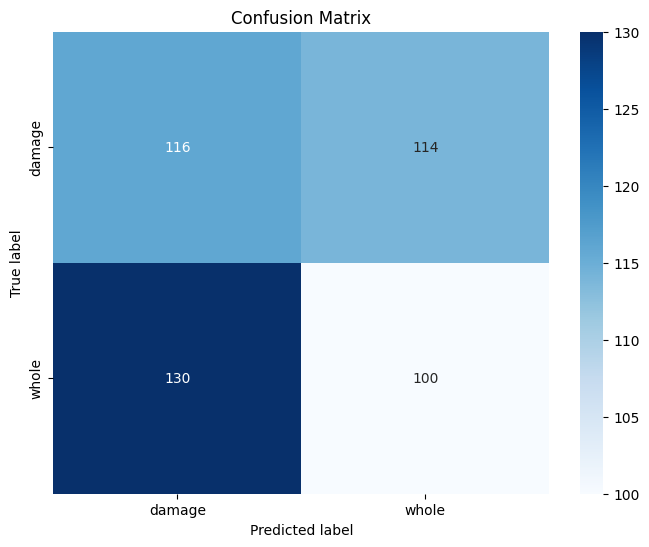

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [29]:
report = classification_report(true_classes,pred,target_names=class_labels)
print(report)

              precision    recall  f1-score   support

      damage       0.47      0.50      0.49       230
       whole       0.47      0.43      0.45       230

    accuracy                           0.47       460
   macro avg       0.47      0.47      0.47       460
weighted avg       0.47      0.47      0.47       460



In [30]:
model.save("./custom-cnn.keras")

### Model Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Whole


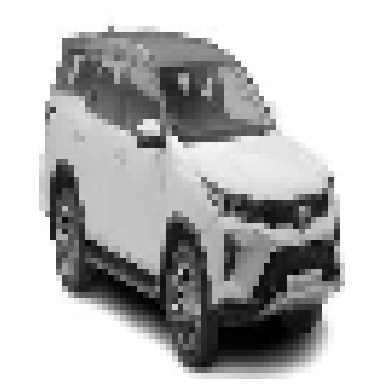

In [220]:
# Load image (grayscale)
img = cv2.imread("./whole.jpg", cv2.IMREAD_GRAYSCALE)

# Resize to model input size (example: 64x64)
img = cv2.resize(img, (img_width, img_height))

plt.imshow(img, "gray")
plt.axis("off")

# Normalize
img = img / 255.0

# Add channel dimension (for grayscale)
img = np.expand_dims(img, axis=-1)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img)

pred_class = np.argmax(pred, axis=1)

if pred_class[0] == 0:
    print("Damage")
else:
    print("Whole")

### Model 2 : Custom CNN with Data Augmentation

In [61]:
train_dir = "./dataset/training"
test_dir = "./dataset/testing"

In [62]:
img_width, img_height = 64, 64
batch_size = 32
epochs = 10
num_class = 2

In [63]:
data_gen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


test_gen = ImageDataGenerator(
    rescale = 1./255
)

In [64]:
train_generator = data_gen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    subset='training'
)


val_generator = data_gen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    subset='validation'
)


test_generator = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

Found 1472 images belonging to 2 classes.
Found 368 images belonging to 2 classes.
Found 460 images belonging to 2 classes.


In [65]:
# model = Sequential()

# model.add(Conv2D(32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(img_width,img_height,1)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(2,2))
# model.add(Dropout(0.2))

# model.add(Conv2D(64,kernel_size=(3,3),activation='relu',padding='same'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(2,2))
# model.add(Dropout(0.2))

# model.add(Conv2D(128,kernel_size=(3,3),activation='relu',padding='same'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(2,2))
# model.add(Dropout(0.2))


# model.add(Flatten())

# model.add(Dense(128,activation='relu'))
# model.add(Dropout(0.4))

# model.add(Dense(64,activation='relu'))
# model.add(Dropout(0.4))



# model.add(Dense(num_class,activation='softmax'))

# model.summary()

# --------------------------------------------------------------------------------

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),activation='relu',padding='same',input_shape=(img_width,img_height,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(128,kernel_size=(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(256,kernel_size=(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(num_class,activation='softmax'))

model.summary()

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 922,562 (3.52 MB)

 Trainable params: 921,602 (3.52 MB)

 Non-trainable params: 960 (3.75 KB)

In [66]:
earlystop = EarlyStopping(
    monitor='val_loss',
    # min_delta=0,
    patience=10,
    verbose=1,
    restore_best_weights=True
    )

In [67]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [68]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=30,
    callbacks=[earlystop]
)

Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.5251 - loss: 1.4446 - val_accuracy: 0.5057 - val_loss: 0.7887
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.5251 - loss: 0.7851 - val_accuracy: 0.4972 - val_loss: 1.0910
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.5054 - loss: 0.7299 - val_accuracy: 0.4972 - val_loss: 0.7619
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.4830 - loss: 0.7053 - val_accuracy: 0.4943 - val_loss: 0.9682
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.5258 - loss: 0.6978 - val_accuracy: 0.4943 - val_loss: 0.8238
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.5061 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.8773
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.5109 - loss: 0.6955 - val_accuracy: 0.5028 - val_loss: 0.9436
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 267ms/step - accuracy: 0.5075 - loss: 0.6891 - val_accuracy:

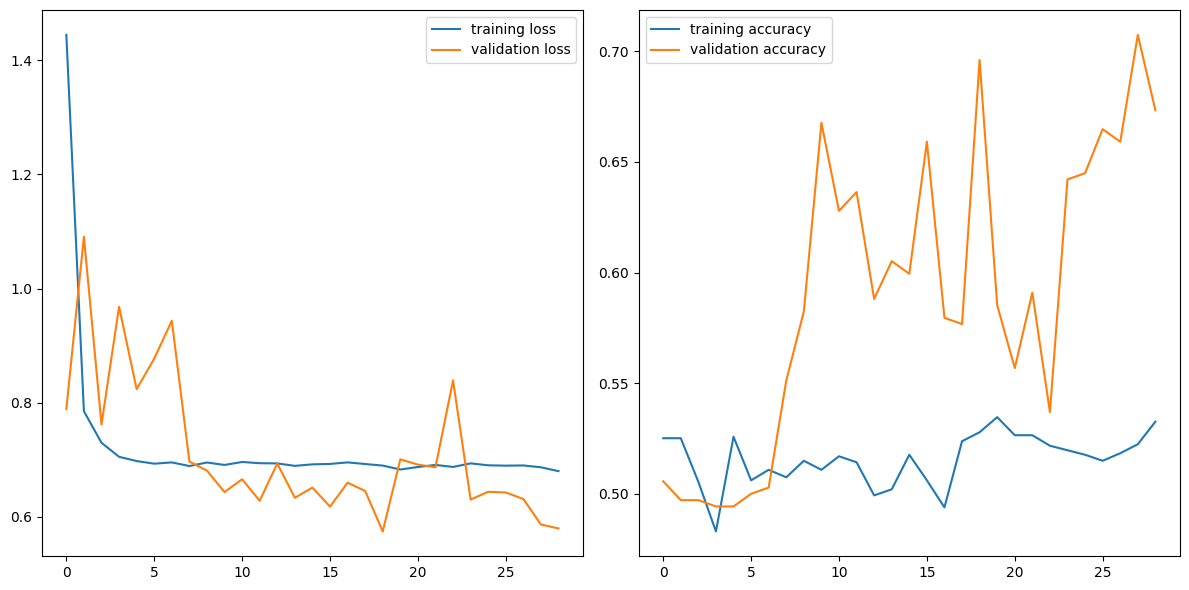

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.lineplot(x=range(len(history.history["loss"])), y=history.history["loss"], ax=ax[0], label="training loss")
sns.lineplot(x=range(len(history.history["val_loss"])), y=history.history["val_loss"], ax=ax[0], label="validation loss")
sns.lineplot(x=range(len(history.history["accuracy"])), y=history.history["accuracy"], ax=ax[1], label="training accuracy")
sns.lineplot(x=range(len(history.history["val_accuracy"])), y=history.history["val_accuracy"], ax=ax[1], label="validation accuracy")

# sns.lineplot(history.history["loss"], ax=ax[0], label="training loss")
# sns.lineplot(history.history["val_loss"], ax=ax[0], label="validation loss")

# sns.lineplot(history.history["accuracy"], ax=ax[1], label="training accuracy")
# sns.lineplot(history.history["val_accuracy"], ax=ax[1], label="validation accuracy")

plt.tight_layout()
plt.show()

In [70]:
train_loss, train_accuracy = model.evaluate(train_generator)
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Train Accuracy : {train_accuracy*100:.2f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.5720 - loss: 0.6788
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6109 - loss: 0.6606
Train Accuracy : 57.20
Test Accuracy : 61.09


In [71]:
pred_probs = model.predict(test_generator)
pred = np.argmax(pred_probs, axis=1)
pred

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,

In [72]:
cm = confusion_matrix(test_generator.classes, pred)
cm

array([[148,  82],
       [ 97, 133]])

In [73]:
class_labels = list(test_generator.class_indices.keys())
class_labels

['damage', 'whole']

In [74]:
true_classes = test_generator.classes
true_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

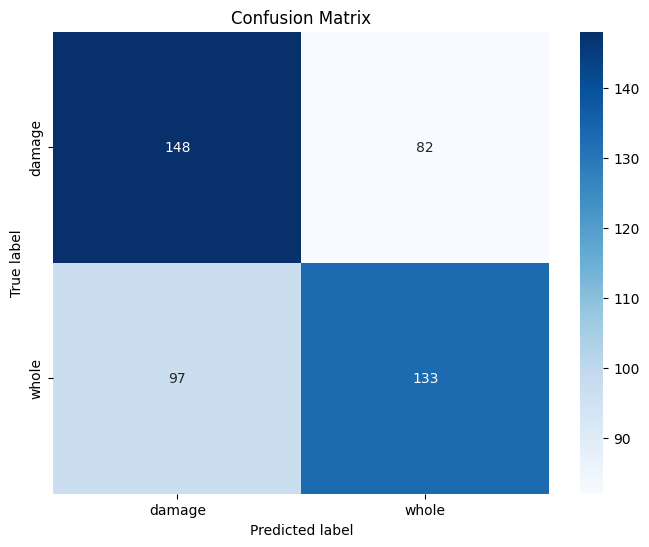

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [76]:
report = classification_report(true_classes,pred,target_names=class_labels)
print(report)

              precision    recall  f1-score   support

      damage       0.60      0.64      0.62       230
       whole       0.62      0.58      0.60       230

    accuracy                           0.61       460
   macro avg       0.61      0.61      0.61       460
weighted avg       0.61      0.61      0.61       460



In [77]:
model.save("./custom-cnn-with-augmentation-2.keras")

### Model Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Whole


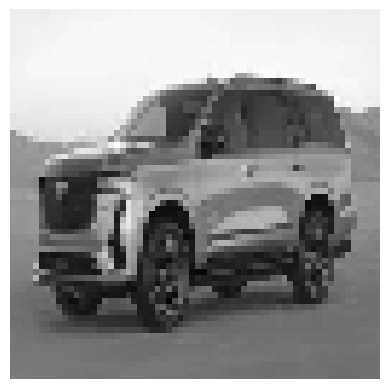

In [85]:
model = keras.models.load_model("./custom-cnn-with-augmentation-2.keras")

# Load image (grayscale)
img = cv2.imread("./unseen_dataset/w3.jpg", cv2.IMREAD_GRAYSCALE)

# Resize to model input size (example: 64x64)
img = cv2.resize(img, (64, 64))

plt.imshow(img, "gray")
plt.axis("off")

# Normalize
img = img / 255.0

# Add channel dimension (for grayscale)
img = np.expand_dims(img, axis=-1)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Predict
pred = model.predict(img)

pred_class = np.argmax(pred, axis=1)

if pred_class[0] == 0:
    print("Damage")
else:
    print("Whole")